In [480]:
import pandas as pd
import matplotlib.pyplot as plt

In [481]:
df=pd.read_csv("train.csv")

In [482]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [483]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [484]:
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [485]:
df["Dependents"].unique()

<ArrowStringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str

In [486]:
df["Dependents"]=df["Dependents"].str.replace('+',"")

In [487]:
cate=["Gender","Married","Dependents","Self_Employed","Loan_Amount_Term","Credit_History"]
for i in cate:
    df[i]=df[i].fillna(df[i].mode()[0])

In [488]:
df.isna().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [489]:
df["LoanAmount"]=df["LoanAmount"].fillna(df["LoanAmount"].mean())

In [490]:
df.drop(columns=["Loan_ID"],inplace=True)

In [491]:
df.duplicated

<bound method DataFrame.duplicated of      Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0      Male      No          0      Graduate            No             5849   
1      Male     Yes          1      Graduate            No             4583   
2      Male     Yes          0      Graduate           Yes             3000   
3      Male     Yes          0  Not Graduate            No             2583   
4      Male      No          0      Graduate            No             6000   
..      ...     ...        ...           ...           ...              ...   
609  Female      No          0      Graduate            No             2900   
610    Male     Yes          3      Graduate            No             4106   
611    Male     Yes          1      Graduate            No             8072   
612    Male     Yes          2      Graduate            No             7583   
613  Female      No          0      Graduate           Yes             4583   

     Coapplic

In [492]:
df.drop_duplicates(inplace=True)

In [493]:
loan=df["Loan_Status"].value_counts()
loan

Loan_Status
Y    422
N    192
Name: count, dtype: int64

<BarContainer object of 2 artists>

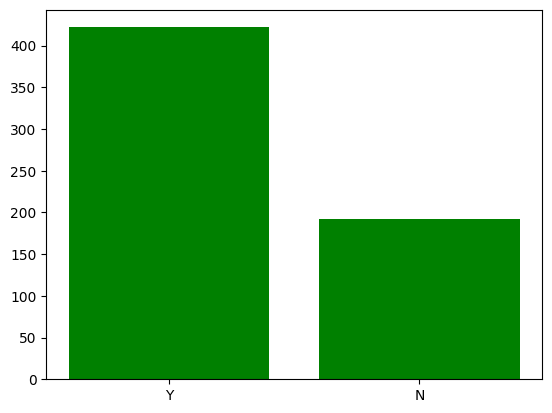

In [494]:
plt.bar(loan.index,loan.values,color="g")

In [495]:
df.dtypes

Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

In [496]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [497]:
columns=["Gender","Married","Dependents","Education","Self_Employed","Property_Area","Loan_Status"]
for i in columns:
    df[i]=le.fit_transform(df[i])

In [498]:
x=df.drop(columns="Loan_Status")
y=df["Loan_Status"]

In [499]:
from sklearn.model_selection import train_test_split

In [500]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=42)

In [501]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(x_train)
x_train=scaler.transform(x_train)
x_test=scaler.transform(x_test)

In [502]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

knn=KNeighborsClassifier(n_neighbors=9)
svm=SVC()
nb=GaussianNB()

lst=[knn,svm,nb]

In [503]:
for i in lst:
    print("model selection_______________",i)
    print(i.fit(x_train,y_train))
    y_pred=i.predict(x_test)

    print("confusion_matrix________________",i)
    print(confusion_matrix(y_test,y_pred))


    print("accuracy_score_________________",i)
    print(accuracy_score(y_test,y_pred))

model selection_______________ KNeighborsClassifier(n_neighbors=9)
KNeighborsClassifier(n_neighbors=9)
confusion_matrix________________ KNeighborsClassifier(n_neighbors=9)
[[22 32]
 [ 1 99]]
accuracy_score_________________ KNeighborsClassifier(n_neighbors=9)
0.7857142857142857
model selection_______________ SVC()
SVC()
confusion_matrix________________ SVC()
[[21 33]
 [ 1 99]]
accuracy_score_________________ SVC()
0.7792207792207793
model selection_______________ GaussianNB()
GaussianNB()
confusion_matrix________________ GaussianNB()
[[23 31]
 [ 3 97]]
accuracy_score_________________ GaussianNB()
0.7792207792207793
